# Ablation study

In [19]:
import pandas as pd

## No Subject

Investigate the effects of removing Subject from model input, i.e. setting the field to null.

We can then compare the model output resulting from this with the one that included Subject in order to gauge the effect of substituting journal_display_name with Subject:

Title + Abstract + Citations (PDF metadata)\
vs\
Title + Abstract + Citations (PDF metadata) + **Subject**


In [ ]:
# Import Proposals_ESRF_Predictions_combined_all.json
# Predictions data

import json

# Define the path to the model predictions file
filepath = '{insert path here}/Datasets/Predictions/Proposals_ESRF_Predictions_combined_all.json'

# Open the file in read mode ('r')
with open(filepath, 'r') as f:
    model_pred = json.load(f)

In [ ]:
# Import Proposals_ESRF_Predictions_no_subject.json
# Predictions data

import json

# Define the path to the model predictions file
filepath = '{insert path here}/Datasets/Ablation/Proposals_ESRF_Predictions_no_subject.json'

# Open the file in read mode ('r')
with open(filepath, 'r') as f:
    model_pred_no_subject = json.load(f)

In [22]:
# Convert the lists of dicts to dataframes for easier analysis
df_pred = pd.DataFrame(model_pred)
df_pred_no_subject = pd.DataFrame(model_pred_no_subject)

# Join df_pred and df_pred_no_subject based on 'proposal_number'
df_ablation = pd.merge(df_pred, df_pred_no_subject[['proposal_number','journal_display_name','topic_predictions_no_subject']], on='proposal_number', suffixes=('_base', '_no_subject'))


In [23]:
# Function to check for differences in model predictions for proposals with Subject metadata vs. those without
def check_prediction_differences(row):
    topic_predictions_pdf_metadata_only = row['topic_predictions_pdf_metadata_only']
    topic_predictions_no_subject = row['topic_predictions_no_subject']

    ls1 = []
    ls2 = []
    for i in range(len(topic_predictions_pdf_metadata_only)):
        ls1.append(topic_predictions_pdf_metadata_only[i]['topic_id'])
    for i in range(len(topic_predictions_no_subject)):
        ls2.append(topic_predictions_no_subject[i]['topic_id'])

    set1 = set(ls1)
    set2 = set(ls2)

    # Topics in pdf_metadata_only but not in no_subject
    only_in_pdf_metadata = set1 - set2

    # Topics in no_subject but not in pdf_metadata_only
    only_in_no_subject = set2 - set1

    return list(only_in_pdf_metadata), list(only_in_no_subject)

    
    

In [24]:
df_ablation[['diff_metadata_only','diff_no_subject']] = df_ablation.apply(check_prediction_differences, axis=1,result_type='expand')

### Full list of proposals

We analyse the differences in model predictions for all 5384 proposals. However, note that some of these have no Subject in the first place, so we need to filter them out.

In [25]:
print('Total number of proposals:',df_ablation.shape[0])
print('Number of proposals with no Subject in the first place:',df_ablation[df_ablation['journal_display_name_base']==''].shape[0])
print('Number of proposals to analyse:',df_ablation[df_ablation['journal_display_name_base']!=''].shape[0])

Total number of proposals: 5384
Number of proposals with no Subject in the first place: 820
Number of proposals to analyse: 4564


In [26]:
# Proposals to analyse for the ablation study (i.e. those with Subject metadata in the first place)
df_ablation_1 = df_ablation[df_ablation['journal_display_name_base']!='']

print('Number of proposals with different outputs:',df_ablation_1[(df_ablation_1['diff_metadata_only'].apply(len) > 0) | (df_ablation_1['diff_no_subject'].apply(len) > 0)].shape[0])
print('Percentage of proposals with different outputs:',df_ablation_1[(df_ablation_1['diff_metadata_only'].apply(len) > 0) | (df_ablation_1['diff_no_subject'].apply(len) > 0)].shape[0] / df_ablation_1.shape[0] * 100,'%')

Number of proposals with different outputs: 353
Percentage of proposals with different outputs: 7.73444347063979 %


### The 209 proposals

We analyse the differences in model predictions for just the 209 proposals used in the evaluation exercise. The expert evaluations enable us to carry out a more in-depth analysis.

In [ ]:
# Import evaluation exercise data
# Evaluation_exercise data

# We need the evaluation exercise data to filter for the 209 proposals from the total of 5384 proposals

pathname = '{insert path here}/Datasets/Evaluation_exercise/results_spreadsheet.xlsx'
df = pd.read_excel(pathname)
df.drop(columns=['Unnamed: 0'], inplace=True)

In [28]:
# Filter for the 209 proposals in the evaluation exercise

# List of the 209 proposal numbers in the evaluation exercise
prop_for_validation_ls = list(df['Proposal number'].unique())

# Filter the ablation dataframe for the proposals in the evaluation exercise
df_ablation_2 = df_ablation[df_ablation['proposal_number'].isin(prop_for_validation_ls)]


In [29]:
print('Number of proposals with different outputs:',df_ablation_2[(df_ablation_2['diff_metadata_only'].apply(len) > 0) | (df_ablation_2['diff_no_subject'].apply(len) > 0)].shape[0])
print('Percentage of proposals with different outputs:',df_ablation_2[(df_ablation_2['diff_metadata_only'].apply(len) > 0) | (df_ablation_2['diff_no_subject'].apply(len) > 0)].shape[0] / df_ablation_2.shape[0] * 100,'%')

Number of proposals with different outputs: 10
Percentage of proposals with different outputs: 4.784688995215311 %


In [30]:
print('List of proposals with different outputs:')
print(df_ablation_2[(df_ablation_2['diff_metadata_only'].apply(len) > 0) | (df_ablation_2['diff_no_subject'].apply(len) > 0)][['proposal_number','diff_metadata_only','diff_no_subject']])

List of proposals with different outputs:
     proposal_number diff_metadata_only diff_no_subject
397          CH-5953            [11279]         [10612]
442          CH-6158            [10152]         [10955]
1018         ES-1266            [11733]         [11073]
3778         MA-4760            [13104]              []
4859         MX-2415            [12104]         [10118]
4881         MX-2443            [11162]         [11482]
5137         SC-5103            [10343]         [11366]
5182         SC-5228            [10666]         [12813]
5220         SC-5319            [10729]         [10176]
5245         SC-5384            [11799]         [10405]


| Proposal number | Topic ID and label | Average score |
|---|---|---|
| CH-5953 | 11279: Lanthanide and Transition Metal Complexes | 0.667 |
| CH-6158 | 10152: Animal Nutrition and Physiology | 0.5 |
| ES-1266 | 11733: X-ray Spectroscopy and Fluorescence Analysis | 0.833 |
| MA-4760 | 13104: Chemical and Physical Properties of Materials | 1 |
| MX-2415 | 12104: Protein Tyrosine Phosphatases | 0.167 |
| MX-2443 | 11162: Enzyme Structure and Function | 0.667 |
| SC-5103 | 10343: Hydrogels: synthesis, properties, applications | 1 |
| SC-5228 | 10666: Photonic Crystals and Applications	| 1 |
| SC-5319 | 10729: Electrospun Nanofibers in Biomedical Applications | 0.167 |
| SC-5384 | 11799: Adhesion, Friction, and Surface Interactions | 0.667 |




## No title

In [ ]:
# Import Proposals_ESRF_Predictions_combined_all.json
# Predictions data

import json

# Define the path to the model predictions file
filepath = '{insert path here}/Datasets/Predictions/Proposals_ESRF_Predictions_combined_all.json'

# Open the file in read mode ('r')
with open(filepath, 'r') as f:
    model_pred = json.load(f)


# Import Proposals_ESRF_Predictions_no_title.json
# Predictions data

import json

# Define the path to the model predictions file
filepath = '{insert path here}/Datasets/Ablation/Proposals_ESRF_Predictions_no_title.json'

# Open the file in read mode ('r')
with open(filepath, 'r') as f:
    model_pred_no_title = json.load(f)



# Convert the lists of dicts to dataframes for easier analysis
df_pred = pd.DataFrame(model_pred)
df_pred_no_title = pd.DataFrame(model_pred_no_title)

# Join df_pred and df_pred_no_title based on 'proposal_number'
df_ablation = pd.merge(df_pred, df_pred_no_title[['proposal_number','journal_display_name','topic_predictions_no_title']], on='proposal_number', suffixes=('_base', '_no_title'))

In [32]:
# Function to check for differences in model predictions for proposals with Title metadata vs. those without
def check_prediction_differences(row):
    topic_predictions_pdf_metadata_only = row['topic_predictions_pdf_metadata_only']
    topic_predictions_no_title = row['topic_predictions_no_title']

    ls1 = []
    ls2 = []
    for i in range(len(topic_predictions_pdf_metadata_only)):
        ls1.append(topic_predictions_pdf_metadata_only[i]['topic_id'])
    for i in range(len(topic_predictions_no_title)):
        ls2.append(topic_predictions_no_title[i]['topic_id'])

    set1 = set(ls1)
    set2 = set(ls2)

    # Topics in pdf_metadata_only but not in no_title
    only_in_pdf_metadata = set1 - set2

    # Topics in no_title but not in pdf_metadata_only
    only_in_no_title = set2 - set1

    return list(only_in_pdf_metadata), list(only_in_no_title)

In [33]:
df_ablation[['diff_metadata_only','diff_no_title']] = df_ablation.apply(check_prediction_differences, axis=1,result_type='expand')

### Full list of proposals

We analyse the differences in model predictions for all 5384 proposals. All proposals have a Title.

In [34]:
print('Total number of proposals:',df_ablation.shape[0])
print('Number of proposals with no Title in the first place:',df_ablation[df_ablation['title']==''].shape[0])
print('Number of proposals to analyse:',df_ablation[df_ablation['title']!=''].shape[0])

Total number of proposals: 5384
Number of proposals with no Title in the first place: 0
Number of proposals to analyse: 5384


In [35]:
# Proposals to analyse for the ablation study (i.e. those with Subject metadata in the first place)
df_ablation_1 = df_ablation[df_ablation['title']!='']

print('Number of proposals with different outputs:',df_ablation_1[(df_ablation_1['diff_metadata_only'].apply(len) > 0) | (df_ablation_1['diff_no_title'].apply(len) > 0)].shape[0])
print('Percentage of proposals with different outputs:',df_ablation_1[(df_ablation_1['diff_metadata_only'].apply(len) > 0) | (df_ablation_1['diff_no_title'].apply(len) > 0)].shape[0] / df_ablation_1.shape[0] * 100,'%')

Number of proposals with different outputs: 4178
Percentage of proposals with different outputs: 77.6002971768202 %


### The 209 proposals

We analyse the differences in model predictions for just the 209 proposals used in the evaluation exercise. The expert evaluations enable us to carry out a more in-depth analysis.

In [ ]:
# Import evaluation exercise data
# Evaluation_exercise data

# We need the evaluation exercise data to filter for the 209 proposals from the total of 5384 proposals

pathname = '{insert path here}/Datasets/Evaluation_exercise/results_spreadsheet.xlsx'
df = pd.read_excel(pathname)
df.drop(columns=['Unnamed: 0'], inplace=True)

In [37]:
# Filter for the 209 proposals in the evaluation exercise

# List of the 209 proposal numbers in the evaluation exercise
prop_for_validation_ls = list(df['Proposal number'].unique())

# Filter the ablation dataframe for the proposals in the evaluation exercise
df_ablation_2 = df_ablation[df_ablation['proposal_number'].isin(prop_for_validation_ls)]


In [38]:
print('Number of proposals with different outputs:',df_ablation_2[(df_ablation_2['diff_metadata_only'].apply(len) > 0) | (df_ablation_2['diff_no_title'].apply(len) > 0)].shape[0])
print('Percentage of proposals with different outputs:',df_ablation_2[(df_ablation_2['diff_metadata_only'].apply(len) > 0) | (df_ablation_2['diff_no_title'].apply(len) > 0)].shape[0] / df_ablation_2.shape[0] * 100,'%')

Number of proposals with different outputs: 122
Percentage of proposals with different outputs: 58.3732057416268 %


## No abstract

In [ ]:
# Import Proposals_ESRF_Predictions_combined_all.json
# Predictions data

import json

# Define the path to the model predictions file
filepath = '{insert path here}/Datasets/Predictions/Proposals_ESRF_Predictions_combined_all.json'

# Open the file in read mode ('r')
with open(filepath, 'r') as f:
    model_pred = json.load(f)


# Import Proposals_ESRF_Predictions_no_abstract.json
# Predictions data

import json

# Define the path to the model predictions file
filepath = '{insert path here}/Datasets/Ablation/Proposals_ESRF_Predictions_no_abstract.json'

# Open the file in read mode ('r')
with open(filepath, 'r') as f:
    model_pred_no_abstract = json.load(f)



# Convert the lists of dicts to dataframes for easier analysis
df_pred = pd.DataFrame(model_pred)
df_pred_no_abstract = pd.DataFrame(model_pred_no_abstract)

# Join df_pred and df_pred_no_abstract based on 'proposal_number'
df_ablation = pd.merge(df_pred, df_pred_no_abstract[['proposal_number','journal_display_name','topic_predictions_no_abstract']], on='proposal_number', suffixes=('_base', '_no_abstract'))

In [40]:
# Function to check for differences in model predictions for proposals with Title metadata vs. those without
def check_prediction_differences(row):
    topic_predictions_pdf_metadata_only = row['topic_predictions_pdf_metadata_only']
    topic_predictions_no_abstract = row['topic_predictions_no_abstract']

    ls1 = []
    ls2 = []
    for i in range(len(topic_predictions_pdf_metadata_only)):
        ls1.append(topic_predictions_pdf_metadata_only[i]['topic_id'])
    for i in range(len(topic_predictions_no_abstract)):
        ls2.append(topic_predictions_no_abstract[i]['topic_id'])

    set1 = set(ls1)
    set2 = set(ls2)

    # Topics in pdf_metadata_only but not in no_abstract
    only_in_pdf_metadata = set1 - set2

    # Topics in no_abstract but not in pdf_metadata_only
    only_in_no_abstract = set2 - set1

    return list(only_in_pdf_metadata), list(only_in_no_abstract)

In [41]:
df_ablation[['diff_metadata_only','diff_no_abstract']] = df_ablation.apply(check_prediction_differences, axis=1,result_type='expand')

### Full list of proposals

We analyse the differences in model predictions for all 5384 proposals. Some proposals have no abstract in the first place, so we will need to filter them out.

In [42]:
print('Total number of proposals:',df_ablation.shape[0])
print('Number of proposals with no abstract in the first place:',df_ablation[df_ablation['abstract_inverted_index']==''].shape[0])
print('Number of proposals to analyse:',df_ablation[df_ablation['abstract_inverted_index']!=''].shape[0])

Total number of proposals: 5374
Number of proposals with no abstract in the first place: 306
Number of proposals to analyse: 5068


In [43]:
# Proposals to analyse for the ablation study (i.e. those with abstract metadata in the first place)
df_ablation_1 = df_ablation[df_ablation['abstract_inverted_index']!='']

print('Number of proposals with different outputs:',df_ablation_1[(df_ablation_1['diff_metadata_only'].apply(len) > 0) | (df_ablation_1['diff_no_abstract'].apply(len) > 0)].shape[0])
print('Percentage of proposals with different outputs:',df_ablation_1[(df_ablation_1['diff_metadata_only'].apply(len) > 0) | (df_ablation_1['diff_no_abstract'].apply(len) > 0)].shape[0] / df_ablation_1.shape[0] * 100,'%')

Number of proposals with different outputs: 4565
Percentage of proposals with different outputs: 90.07498026835043 %


### The 209 proposals

We analyse the differences in model predictions for just the 209 proposals used in the evaluation exercise. The expert evaluations enable us to carry out a more in-depth analysis.

In [ ]:
# Import evaluation exercise data
# Evaluation_exercise data

# We need the evaluation exercise data to filter for the 209 proposals from the total of 5384 proposals

pathname = '{insert path here}/Datasets/Evaluation_exercise/results_spreadsheet.xlsx'
df = pd.read_excel(pathname)
df.drop(columns=['Unnamed: 0'], inplace=True)

In [45]:
# Filter for the 209 proposals in the evaluation exercise

# List of the 209 proposal numbers in the evaluation exercise
prop_for_validation_ls = list(df['Proposal number'].unique())

# Filter the ablation dataframe for the proposals in the evaluation exercise
df_ablation_2 = df_ablation[df_ablation['proposal_number'].isin(prop_for_validation_ls)]


In [46]:
print('Number of proposals with different outputs:',df_ablation_2[(df_ablation_2['diff_metadata_only'].apply(len) > 0) | (df_ablation_2['diff_no_abstract'].apply(len) > 0)].shape[0])
print('Percentage of proposals with different outputs:',df_ablation_2[(df_ablation_2['diff_metadata_only'].apply(len) > 0) | (df_ablation_2['diff_no_abstract'].apply(len) > 0)].shape[0] / df_ablation_2.shape[0] * 100,'%')

Number of proposals with different outputs: 184
Percentage of proposals with different outputs: 88.03827751196172 %


## No citations

In [ ]:
# Import Proposals_ESRF_Predictions_combined_all.json
# Predictions data

import json

# Define the path to the model predictions file
filepath = '{insert path here}/Datasets/Predictions/Proposals_ESRF_Predictions_combined_all.json'

# Open the file in read mode ('r')
with open(filepath, 'r') as f:
    model_pred = json.load(f)


# Import Proposals_ESRF_Predictions_no_citations.json
# Predictions data

import json

# Define the path to the model predictions file
filepath = '{insert path here}/Datasets/Ablation/Proposals_ESRF_Predictions_no_citations.json'

# Open the file in read mode ('r')
with open(filepath, 'r') as f:
    model_pred_no_citations = json.load(f)



# Convert the lists of dicts to dataframes for easier analysis
df_pred = pd.DataFrame(model_pred)
df_pred_no_citations = pd.DataFrame(model_pred_no_citations)

# Join df_pred and df_pred_no_citations based on 'proposal_number'
df_ablation = pd.merge(df_pred, df_pred_no_citations[['proposal_number','journal_display_name','topic_predictions_no_citations']], on='proposal_number', suffixes=('_base', '_no_citations'))

In [48]:
# Function to check for differences in model predictions for proposals with Title metadata vs. those without
def check_prediction_differences(row):
    topic_predictions_pdf_metadata_only = row['topic_predictions_pdf_metadata_only']
    topic_predictions_no_citations = row['topic_predictions_no_citations']

    ls1 = []
    ls2 = []
    for i in range(len(topic_predictions_pdf_metadata_only)):
        ls1.append(topic_predictions_pdf_metadata_only[i]['topic_id'])
    for i in range(len(topic_predictions_no_citations)):
        ls2.append(topic_predictions_no_citations[i]['topic_id'])

    set1 = set(ls1)
    set2 = set(ls2)

    # Topics in pdf_metadata_only but not in no_citations
    only_in_pdf_metadata = set1 - set2

    # Topics in no_citations but not in pdf_metadata_only
    only_in_no_citations = set2 - set1

    return list(only_in_pdf_metadata), list(only_in_no_citations)

In [49]:
df_ablation[['diff_metadata_only','diff_no_citations']] = df_ablation.apply(check_prediction_differences, axis=1,result_type='expand')

### Full list of proposals

We analyse the differences in model predictions for all 5384 proposals. Some proposals have no citations in the first place, so we will need to filter them out.

In [50]:
print('Total number of proposals:',df_ablation.shape[0])
print('Number of proposals with no citations in the first place:',df_ablation[df_ablation['referenced_works_doi'].apply(len) == 0].shape[0])
print('Number of proposals to analyse:',df_ablation[df_ablation['referenced_works_doi'].apply(len) > 0].shape[0])

Total number of proposals: 5384
Number of proposals with no citations in the first place: 5136
Number of proposals to analyse: 248


In [51]:
# Proposals to analyse for the ablation study (i.e. those with citations metadata in the first place)
df_ablation_1 = df_ablation[df_ablation['referenced_works_doi'].apply(len) > 0]

print('Number of proposals with different outputs:',df_ablation_1[(df_ablation_1['diff_metadata_only'].apply(len) > 0) | (df_ablation_1['diff_no_citations'].apply(len) > 0)].shape[0])
print('Percentage of proposals with different outputs:',df_ablation_1[(df_ablation_1['diff_metadata_only'].apply(len) > 0) | (df_ablation_1['diff_no_citations'].apply(len) > 0)].shape[0] / df_ablation_1.shape[0] * 100,'%')

Number of proposals with different outputs: 153
Percentage of proposals with different outputs: 61.693548387096776 %


### The 209 proposals

We analyse the differences in model predictions for just the 209 proposals used in the evaluation exercise. The expert evaluations enable us to carry out a more in-depth analysis.

In [ ]:
# Import evaluation exercise data
# Evaluation_exercise data

# We need the evaluation exercise data to filter for the 209 proposals from the total of 5384 proposals

pathname = '{insert path here}/Datasets/Evaluation_exercise/results_spreadsheet.xlsx'
df = pd.read_excel(pathname)
df.drop(columns=['Unnamed: 0'], inplace=True)

In [53]:
# Filter for the 209 proposals in the evaluation exercise

# List of the 209 proposal numbers in the evaluation exercise
prop_for_validation_ls = list(df['Proposal number'].unique())

# Filter the ablation dataframe for the proposals in the evaluation exercise
df_ablation_2 = df_ablation[df_ablation['proposal_number'].isin(prop_for_validation_ls)]


In [54]:
print('Number of proposals with different outputs:',df_ablation_2[(df_ablation_2['diff_metadata_only'].apply(len) > 0) | (df_ablation_2['diff_no_citations'].apply(len) > 0)].shape[0])
print('Percentage of proposals with different outputs:',df_ablation_2[(df_ablation_2['diff_metadata_only'].apply(len) > 0) | (df_ablation_2['diff_no_citations'].apply(len) > 0)].shape[0] / df_ablation_2.shape[0] * 100,'%')

Number of proposals with different outputs: 129
Percentage of proposals with different outputs: 61.72248803827751 %


In [55]:
print('List of proposals with different outputs:')
print(df_ablation_2[(df_ablation_2['diff_metadata_only'].apply(len) > 0) | (df_ablation_2['diff_no_citations'].apply(len) > 0)][['proposal_number','diff_metadata_only','diff_no_citations']])

List of proposals with different outputs:
     proposal_number diff_metadata_only diff_no_citations
380          CH-5879            [10939]           [14363]
390          CH-5900            [12155]           [11381]
402          CH-5986            [10413]           [10807]
417          CH-6065            [10192]           [10030]
420          CH-6073            [10798]           [12613]
...              ...                ...               ...
5238         SC-5368            [10666]                []
5239         SC-5369            [10059]           [12110]
5244         SC-5382            [10474]           [13650]
5245         SC-5384            [11799]           [10405]
5249         SC-5391     [13526, 10303]           [10171]

[129 rows x 3 columns]


## Citation features

We have found that the Title and Abstract seem to have the most influence on the model output. However, we can expect them to always be provided with the proposals. What's unclear is whether we can expect to have the Citations.

We want to first investigate why certain proposals have referenced works. It could be that more recent proposals tend to feature citations, in which case we can assume that any proposals processed by the live service would have citations.

We also want to check if there is a correlation between number of Citations and model performance.

In [ ]:
import json

# Define the path to the model predictions file
filepath = '{insert path here}/Datasets/Predictions/Proposals_ESRF_Predictions_combined_all.json'

# Open the file in read mode ('r')
with open(filepath, 'r') as f:
    model_pred = json.load(f)


import pandas as pd
df_pred = pd.DataFrame(model_pred)

In [ ]:
# Get the date collected metadata for each of the 5384 proposals in the dataset

import requests

# Function to fetch datetime information using API call

def fetch_data(doi):
    doi = doi[0]
    api_request="https://icatplus.esrf.fr/doi/"
    response = requests.get(api_request+doi+'/json-datacite')

    # Check for valid API call status code
    if response.status_code==200:
        reports_esrf=response.json()
        if 'dates' in reports_esrf:
            date_ls = reports_esrf['dates']
            for item in date_ls:
                if item['dateType'] == 'Collected':
                    year = item['date'].split("-")[0]
                    return year    # return the date collected if 'dates' key is in the API response and contains the relevant information
        else:
            return 0    # return 0 if 'dates' key is not in the API response

        return reports_esrf     # return the fetched data
    else:
        return 0        # return 0 if API call result is invalid

In [ ]:
# Apply the function to the 'experiment_session_doi' column to create a new column with the date collected information
# Note that this will take a while to run as it needs to make an API call for each of the 5384 proposals in the dataset

df_pred['year_collected'] = df_pred['experiment_session_doi'].apply(fetch_data)

In [ ]:
# # Export list to json format
# # Ablation data

# filepath = '{insert path here}/Datasets/Ablation/Proposals_ESRF_Predictions_with_year.json'
# df_pred.to_json(filepath, orient='records', indent=2)

In [ ]:
# # Code to import the data back in for analysis if needed
# # Ablation data

# import json
# filepath = '{insert path here}/Datasets/Ablation/Proposals_ESRF_Predictions_with_year.json'

# # Open the file in read mode ('r')
# with open(filepath, 'r') as f:
#     model_pred = json.load(f)


# import pandas as pd
# df_pred = pd.DataFrame(model_pred)

In [60]:
df_pred['year_collected'].value_counts()

year_collected
2024    1374
2023    1238
2022    1058
2025     794
2021     557
2018     247
2019      62
2017      27
2020      19
2016       4
2009       1
2011       1
2014       1
2002       1
Name: count, dtype: int64

In [61]:
df_pred[df_pred['referenced_works_doi'].str.len() == 0]['year_collected'].value_counts()

year_collected
2024    1374
2023    1180
2022     952
2025     794
2021     489
2018     239
2019      60
2017      25
2020      17
2016       2
2009       1
2011       1
2014       1
2002       1
Name: count, dtype: int64

In [62]:
df_pred[df_pred['referenced_works_doi'].str.len() != 0]['year_collected'].value_counts()

year_collected
2022    106
2021     68
2023     58
2018      8
2016      2
2020      2
2017      2
2019      2
Name: count, dtype: int64

There doesn't seem to be any correlation between the year a proposal is collected and whether it has references.

In [ ]:
# Import evaluation exercise data
# Evaluation_exercise data

# We need the evaluation exercise data to filter for the 209 proposals from the total of 5384 proposals

pathname = '{insert path here}/Datasets/Evaluation_exercise/results_spreadsheet.xlsx'
df = pd.read_excel(pathname)
df.drop(columns=['Unnamed: 0'], inplace=True)

df = df[df['Type'].isin(['Predicted Topic 1', 'Predicted Topic 2', 'Predicted Topic 3'])]

In [64]:
# Convert human evaluation to numerical scores for easier analysis
score = {'Relevant': 1, 'Not relevant': 0, 'Unclear': 0.5}
df['Score'] = df['Evaluation'].apply(lambda x: score[x] if pd.notna(x) else x)

# Calculate mean evaluation per Proposal number
df = df.groupby(['Proposal number','Label'])['Score'].mean().reset_index()

# Merge the dataframes to get the 'referenced_works' column from df_pred
df = pd.merge(df, df_pred[['proposal_number','referenced_works_doi']], left_on='Proposal number', right_on='proposal_number')

# Create a new column with the count of referenced works
df['count'] = df['referenced_works_doi'].apply(lambda x: len(x) if isinstance(x, list) else 0)

In [65]:
print('Average number of referenced works for all 209 proposals:', df['count'].mean())

Average number of referenced works for all 209 proposals: 6.15814696485623


Pearson correlation: -0.0136 (p-value: 0.7334)
Spearman correlation: 0.0271 (p-value: 0.4986)


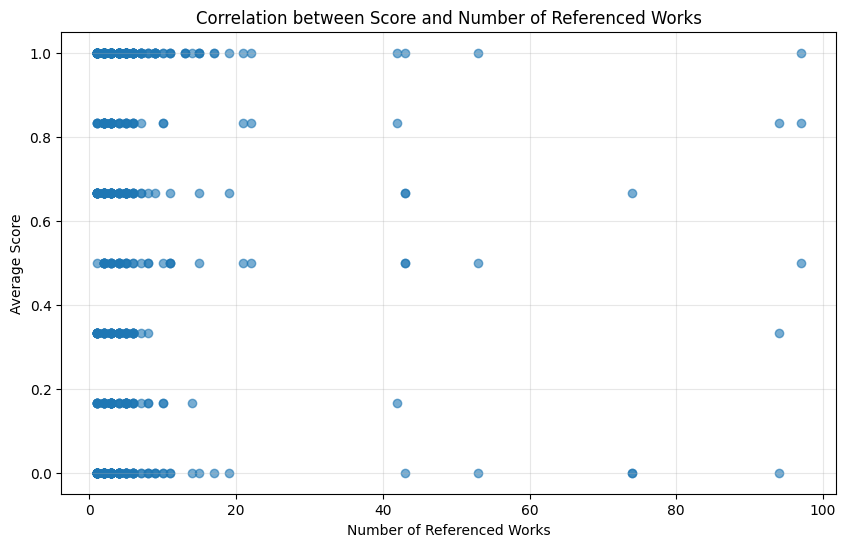

In [66]:
from scipy.stats import pearsonr, spearmanr

import matplotlib.pyplot as plt

# Calculate correlation coefficients
pearson_corr, pearson_pval = pearsonr(df['count'], df['Score'])
spearman_corr, spearman_pval = spearmanr(df['count'], df['Score'])

print(f"Pearson correlation: {pearson_corr:.4f} (p-value: {pearson_pval:.4f})")
print(f"Spearman correlation: {spearman_corr:.4f} (p-value: {spearman_pval:.4f})")

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['count'], df['Score'], alpha=0.6)
plt.xlabel('Number of Referenced Works')
plt.ylabel('Average Score')
plt.title('Correlation between Score and Number of Referenced Works')
plt.grid(True, alpha=0.3)
plt.show()

The correlation between number of referenced works and the average reviewer score is low. This suggests that the model performs well even with sparse referencing, only struggling with a complete absence of referenced works.